# Importing libraries

In [5]:
import json
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy.stats import zscore
import importlib
# Import the user-defined module
import sys
sys.path.append(r'D:\House_data\src')
import eda
import preprocess 
importlib.reload(preprocess)
importlib.reload(eda)


Libraries imported successfully...


<module 'eda' from 'D:\\House_data\\src\\eda.py'>

# Importing House data dataset

In [6]:
house_data = pd.read_csv(r'D:\House_data\raw_data\house_data.csv')
house_data.head(3)



,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062


In [7]:
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [8]:
house_data.shape

(21613, 21)

## Data engineering

In [9]:
# import feature mapping
with open (r"D:\House_data\src\feature_eng_map.json","r") as f:
    feature_mapping = json.load(f)
# preprocess data: date and feature engineering
house_eng_data = preprocess.preprocess_dates(house_data, 'date')
house_eng_data = preprocess.flag_zero_values(house_eng_data)
house_eng_data = preprocess.feature_engineer(house_eng_data, **feature_mapping)

# cleaning yr_renovation and yr_since_renovation columns
# correcting the misscalulation on houses not renovated
house_eng_data['yr_since_renovation']= np.where(house_eng_data['yr_renovated_flag']==1,
                                                house_eng_data['year']-house_eng_data['yr_renovated'],
                                                np.nan)

# fixing the negative values in yr_since_renovation column
house_eng_data.loc[house_eng_data['yr_since_renovation'] < 0, 'yr_since_renovation'] = np.nan


In [10]:
print (f"dimentions of the original dataset: {house_data.shape}")
print (f"dimentions of the new dataset: {house_eng_data.shape}")
print (f"Columns in the new dataset:")
print (*house_eng_data.columns,sep='\n')

dimentions of the original dataset: (21613, 21)
dimentions of the new dataset: (21613, 47)
Columns in the new dataset:
id
date
price
bedrooms
bathrooms
sqft_living
sqft_lot
floors
waterfront
view
condition
grade
sqft_above
sqft_basement
yr_built
yr_renovated
zipcode
lat
long
sqft_living15
sqft_lot15
year
month
quartile
day
day_of_week
bedrooms_flag
bathrooms_flag
waterfront_flag
view_flag
sqft_basement_flag
yr_renovated_flag
day_of_week_flag
house_age
yr_since_renovation
basement_ratio
living_lot_ratio
price_per_sqft
sqft_living_diff
sqft_lot_diff
above_ratio
total_rooms
bath_bed_ratio
overall_quality
luxury_score
grade_sqft_living
waterfront_view_interaction


In [11]:
# yr_since_renovation and yr_renovated corrected
house_eng_data.groupby(['yr_since_renovation','yr_renovated'])['price'].median().reset_index().sort_values(by=['yr_since_renovation'],ascending=[True]).head(10)    

,yr_since_renovation,yr_renovated,price
0,0.0,2014,604500.0
1,0.0,2015,648000.0
2,1.0,2013,547500.0
3,1.0,2014,524950.0
4,2.0,2012,622500.0
5,2.0,2013,700000.0
6,3.0,2011,650000.0
7,3.0,2012,404500.0
8,4.0,2010,765000.0
9,4.0,2011,356500.0


In [12]:
# exploring house engineered data
house_eng_data.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,price_per_sqft,sqft_living_diff,sqft_lot_diff,above_ratio,total_rooms,bath_bed_ratio,overall_quality,luxury_score,grade_sqft_living,waterfront_view_interaction
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0,0,...,188.05,160,0,1.00,4.00,0.33,21,7,8260,0
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0,0,...,209.34,880,397,0.84,5.25,0.75,21,7,17990,0
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0,0,...,233.77,1950,1938,1.00,3.00,0.50,18,6,4620,0
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0,0,...,308.16,600,0,0.54,7.00,0.75,35,7,13720,0
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0,0,...,303.57,120,577,1.00,5.00,0.67,24,8,13440,0


In [13]:
house_eng_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           21613 non-null  int64  
 1   date                         21613 non-null  object 
 2   price                        21613 non-null  float64
 3   bedrooms                     21613 non-null  int64  
 4   bathrooms                    21613 non-null  float64
 5   sqft_living                  21613 non-null  int64  
 6   sqft_lot                     21613 non-null  int64  
 7   floors                       21613 non-null  float64
 8   waterfront                   21613 non-null  int64  
 9   view                         21613 non-null  int64  
 10  condition                    21613 non-null  int64  
 11  grade                        21613 non-null  int64  
 12  sqft_above                   21613 non-null  int64  
 13  sqft_basement              

In [14]:
# identifying new columns in the engineered dataset
new_col= [col for col in house_eng_data.columns if col not in house_data.columns]
new_col.remove("day_of_week_flag")
print(f"New columns in house_eng_data:\n {new_col}")

New columns in house_eng_data:
 ['year', 'month', 'quartile', 'day', 'day_of_week', 'bedrooms_flag', 'bathrooms_flag', 'waterfront_flag', 'view_flag', 'sqft_basement_flag', 'yr_renovated_flag', 'house_age', 'yr_since_renovation', 'basement_ratio', 'living_lot_ratio', 'price_per_sqft', 'sqft_living_diff', 'sqft_lot_diff', 'above_ratio', 'total_rooms', 'bath_bed_ratio', 'overall_quality', 'luxury_score', 'grade_sqft_living', 'waterfront_view_interaction']


# Visualization and Reporting 

## Price vs year and quartile

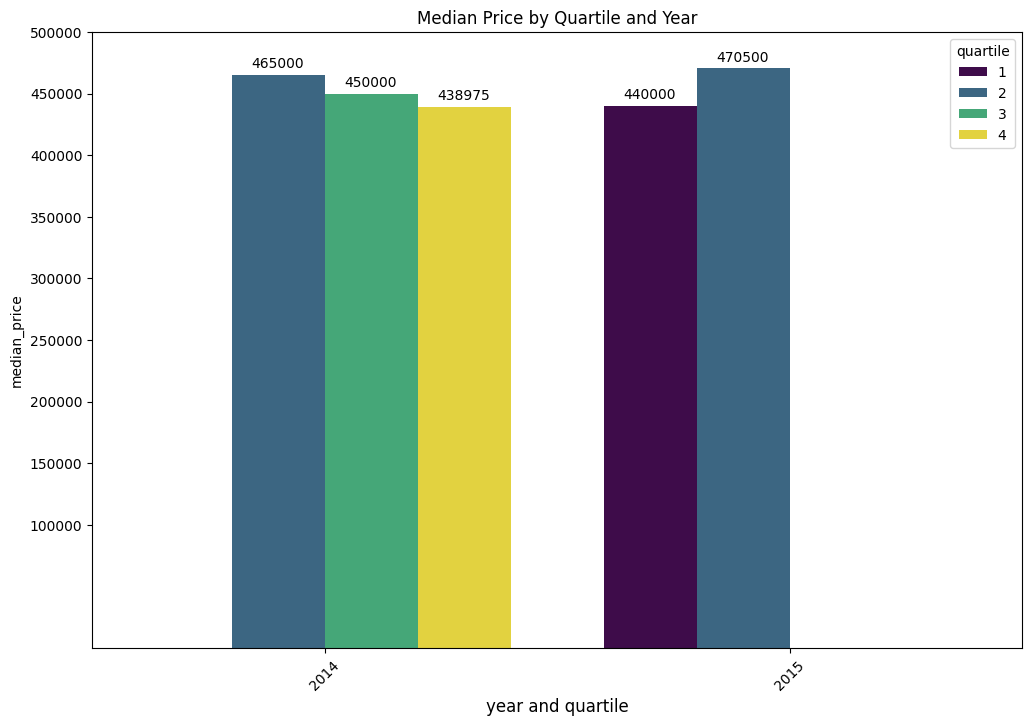

In [15]:
plt.figure(figsize=(12,8))
counts =house_eng_data.groupby(['year','quartile'])['price'].median().reset_index(name='median_price')
ax = sns.barplot(data=counts, x='year', y='median_price', hue='quartile',palette="viridis")
plt.xticks(rotation=45,ha='center')
plt.yticks(np.arange(100000, 550000, 50000))
plt.xlabel("year and quartile", fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=10, color='black', padding=3)
plt.title('Median Price by Quartile and Year')
plt.show()
report5= f''' 
Median Price by Quartile and Year: house sales are highest in quartile 2 in both 2014 and 2015,\n while quartile 1 has the lowest median price in both years.
Year and Quartile of highest price:
{counts.nlargest(2,"median_price")}\n
Year and Quartile of lowest price
{counts.nsmallest(2,"median_price")}
'''

## House sold per day of week

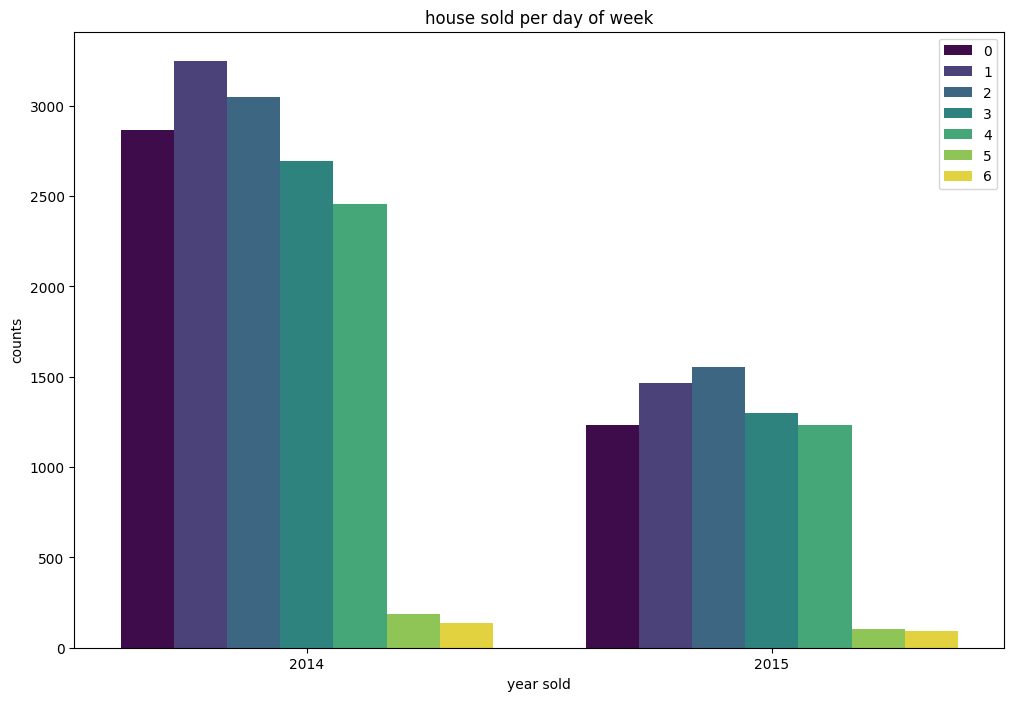

In [16]:
plt.figure(figsize=(12,8))
dayofweek_count = house_eng_data[["year","day_of_week"]].value_counts().reset_index(name="counts").sort_values(by="day_of_week")
sns.barplot(data=dayofweek_count,x='year',y='counts',hue='day_of_week',palette='viridis')
plt.title("house sold per day of week")
plt.xlabel("year sold")
plt.ylabel('counts')
plt.legend()
plt.show()


## Visualization of the hoiuse location on a street map based on zipcode

In [17]:
# Plotting the location of the houses on a street map based on zipcode
# The price is shown by the size and color of the circles
# The most expensive house was shown in red
# The most economic house was shown in green.
# Others in blue.
import plotly.express as px
import pandas as pd

zipcode_house_map = house_data.groupby("zipcode")[["price","lat", "long"]]\
            .mean()\
            .reset_index()\
            .rename(columns={"price": "avg_price"})

# expenisve house
expensive = zipcode_house_map.loc[zipcode_house_map['avg_price'].idxmax(),["zipcode","avg_price"]]
expensive_zip = expensive['zipcode']
expensive_price = expensive['avg_price']
# economic house
economic = zipcode_house_map.loc[zipcode_house_map["avg_price"].idxmin(),['zipcode',"avg_price"]]
economic_zip = economic['zipcode']
economic_price = economic['avg_price']

zipcode_house_map["highlight"] = "other"
zipcode_house_map.loc[zipcode_house_map["zipcode"] == expensive_zip, "highlight"] = "most expensive"
zipcode_house_map.loc[zipcode_house_map["zipcode"] == economic_zip, "highlight"] = "most economical"

fig = px.scatter_map(
    zipcode_house_map,
    lat="lat",
    lon="long",
    color="highlight",
    size="avg_price",
    size_max=40,
    hover_data={"zipcode": True, "avg_price": True, "lat": False, "long": False},
    zoom=9,
    height=1000,
    color_discrete_map={
        "most expensive": "#d62728",
        "most economical": "#2ca02c",
        "other": "#4B53F1"
    }
)

fig.update_layout(
    mapbox_style="open-street-map",
    title="Average house price by zipcode"
)
fig.show()

report = f'''
the most expensive house lies on {expensive_zip}
the price of this house is {expensive_price/1_000_000:.1f}M usd;
the most economic house lies on zipcode: {economic_zip} and the price is {economic_price/1_000_999:.1f}M usd
from the map houses of expensive prices are at the North and houses with low prices are at the South of the map
'''
print(report)



the most expensive house lies on 98039.0
the price of this house is 2.2M usd;
the most economic house lies on zipcode: 98002.0 and the price is 0.2M usd
from the map houses of expensive prices are at the North and houses with low prices are at the South of the map



## Visualization of Houses sold , built , and renovated

C:\Users\hanya\AppData\Local\Temp\ipykernel_12696\257135523.py:5: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="yr_built",y="price",data=house_data,alpha=0.7,palette='viridis')
C:\Users\hanya\AppData\Local\Temp\ipykernel_12696\257135523.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="yr_renovated", y="price", data=house_data_year_renovated, palette='viridis')


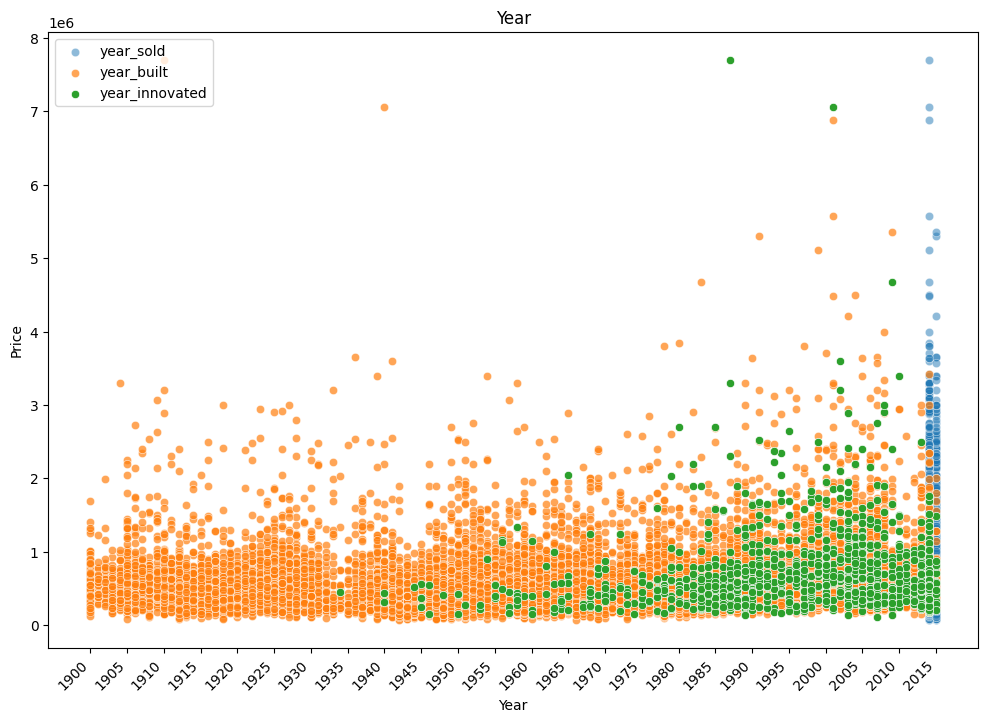

In [15]:
house_data_year_renovated = house_data[house_data["yr_renovated"] != 0]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='year', y='price', data=house_eng_data, alpha=0.5)
sns.scatterplot(x="yr_built",y="price",data=house_data,alpha=0.7,palette='viridis')
sns.scatterplot(x="yr_renovated", y="price", data=house_data_year_renovated, palette='viridis')
plt.xlabel('Year')
plt.ylabel('Price')
plt.xticks(np.arange(1900, 2020, 5), rotation=45, ha='right')
plt.title('Year')
plt.legend(["year_sold","year_built","year_innovated"],loc="upper left")
plt.show()

C:\Users\hanya\AppData\Local\Temp\ipykernel_12696\141703515.py:8: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x="yr_renovated", y="price", data=house_data_year_renovated, palette='viridis')
C:\Users\hanya\AppData\Local\Temp\ipykernel_12696\141703515.py:9: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='year', y="price", data=house_data_notrenovated, palette='viridis')


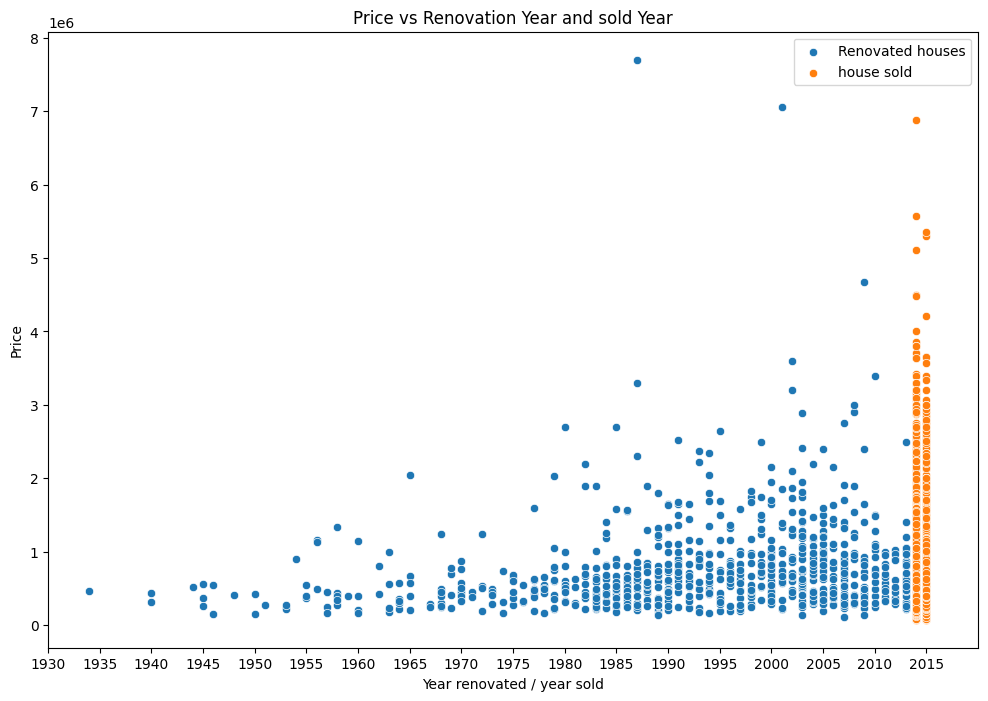


Number of houses most recently sold are 20699
because they are sold on
    year  count
0  2014  13966
1  2015   6733
The oldest renovated was sold on 1934



In [16]:
house_data_year_renovated = house_eng_data[house_data["yr_renovated"] != 0]
house_data_notrenovated = house_eng_data[house_data['yr_renovated'] == 0]
# print(house_data_notrenovated['yr_renovated'].value_counts())
# print(house_data_year_renovated['yr_renovated'].value_counts())


plt.figure(figsize=(12, 8))
sns.scatterplot(x="yr_renovated", y="price", data=house_data_year_renovated, palette='viridis')
sns.scatterplot(x='year', y="price", data=house_data_notrenovated, palette='viridis')
plt.title("Price vs Renovation Year and sold Year")
plt.xlabel("Year renovated / year sold")
plt.ylabel('Price')
plt.xlim(1930, 2020)
plt.xticks(np.arange(1930,2020,5))
plt.legend(["Renovated houses", "house sold"])
plt.show()

report2 = f'''
Number of houses most recently sold are {house_data_notrenovated["yr_renovated"].value_counts().iloc[0]}
because they are sold on\n {pd.DataFrame(house_data_notrenovated['year'].value_counts()).reset_index()}
The oldest renovated was sold on {house_data_year_renovated.loc[house_data_year_renovated['yr_renovated'].idxmin(),"yr_renovated"]}
'''
print (report2)


## Visualization of Houses based on lattitude and longitude

In [17]:
import plotly.express as px
import pandas as pd
plt.figure(figsize=(20, 10))
fig = px.scatter_mapbox(
    house_data,
    lat="lat",
    lon="long",
    color="price",
    size="price",
    zoom=12,
    height=800
)

fig.update_layout(mapbox_style="open-street-map")
fig.show()


C:\Users\hanya\AppData\Local\Temp\ipykernel_12696\2028854773.py:4: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


<Figure size 2000x1000 with 0 Axes>

## Visualzation of houses per decade built

In [18]:
from os import rename


year_built = house_data[["yr_built","price"]]
year_built['decade'] = (year_built['yr_built'] // 10) * 10
year_built = year_built.groupby('decade')['price'].median()\
.reset_index()\
.rename(columns={'decade': 'decade_built', 'price': 'avg_price'})\
.sort_values(by='avg_price', ascending=False)
# year_built = house_data.groupby('decade')['price'].mean()
# year_built = pd.DataFrame(year_built).reset_index().rename(columns={'decade': 'year_built', 'price': 'avg_price'}) 
year_built   

,decade_built,avg_price
0,1900,550000.0
11,2010,539950.0
2,1920,535000.0
1,1910,510750.0
10,2000,495250.0
9,1990,486387.5
3,1930,474000.0
8,1980,450000.0
7,1970,436500.0
5,1950,400000.0


In [19]:
# Estimating the highest and lowest price of houses based on the year built (decades)
max_decade = year_built[year_built['avg_price'] == year_built['avg_price'].max()]["decade_built"].values[0]
min_decade = year_built[year_built['avg_price'] == year_built['avg_price'].min()]["decade_built"].values[0]
max_price = year_built[year_built['avg_price'] == year_built['avg_price'].max()]["avg_price"].values[0]
min_price = year_built[year_built['avg_price'] == year_built['avg_price'].min()]["avg_price"].values[0]
report_decade = f'''
The highest price of houses was built in the decade of {max_decade} with an average price of {max_price/1_000_000:.1f}M USD;
The lowest price of houses was built in the decade of {min_decade} with an average price of {min_price/1_000_000:.1f}M USD;
The plot shows that the houses built in the 1940s and 1960s have the lowest average prices-a price dip,
while those built in the 1900s and 2010s have the highest average prices.
'''
report_decade

'\nThe highest price of houses was built in the decade of 1900 with an average price of 0.6M USD;\nThe lowest price of houses was built in the decade of 1960 with an average price of 0.4M USD;\nThe plot shows that the houses built in the 1940s and 1960s have the lowest average prices-a price dip,\nwhile those built in the 1900s and 2010s have the highest average prices.\n'

In [20]:
print (f"max decade: {max_decade}, max price: {max_price/1_000_000:.1f}M USD")
print (f"min decade: {min_decade}, min price: {min_price/1_000_000:.1f}M USD")

max decade: 1900, max price: 0.6M USD
min decade: 1960, min price: 0.4M USD


In [21]:
# with open(r"D:\House_data\src\report_text.txt", "a") as f:
#     f.write(report_decade)

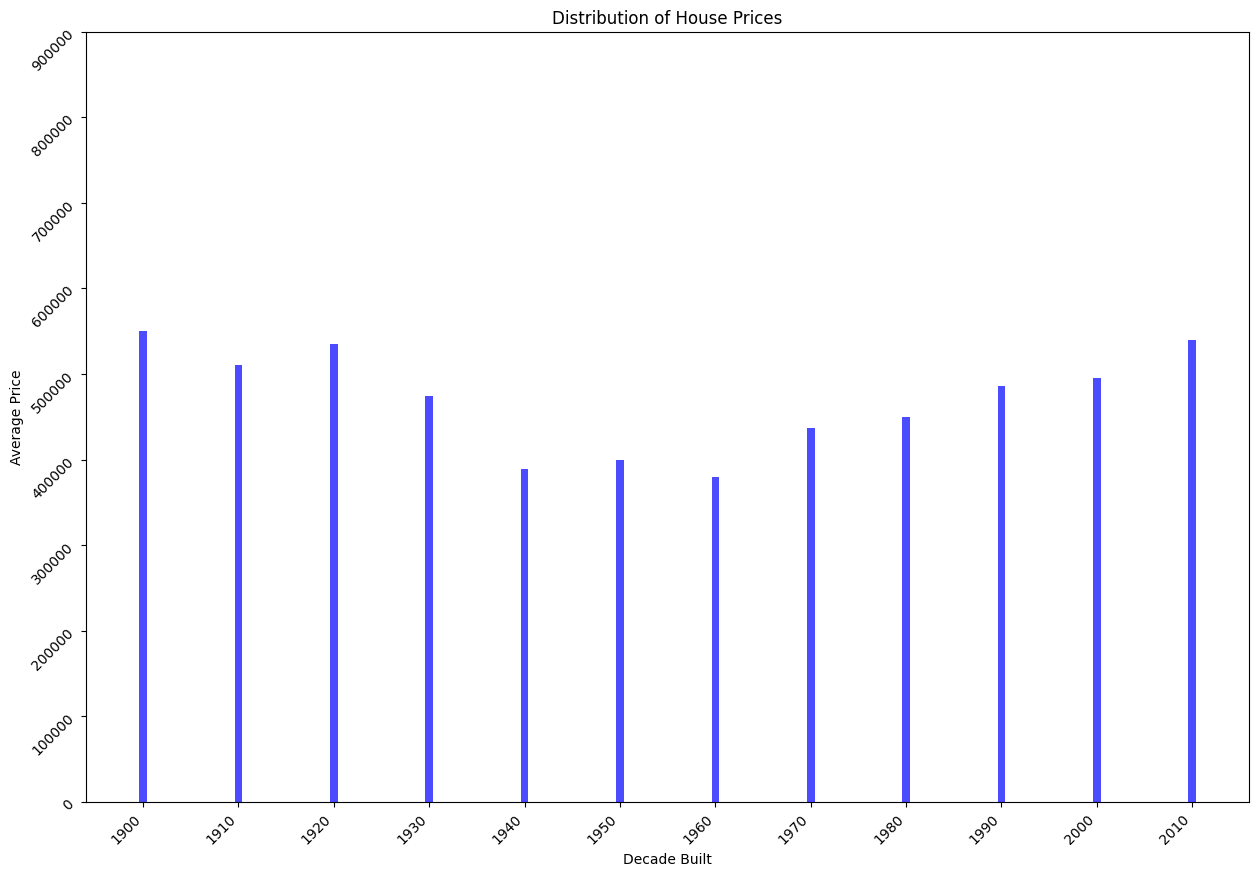

In [22]:
# house_data.info()
plt.figure(figsize=(15, 10))
plt.bar(year_built['decade_built'],year_built["avg_price"], color='blue', alpha=0.7)
# plt.fill_between(year_built['decade_built'], year_built["avg_price"], alpha=0.3,color="red")
plt.title('Distribution of House Prices')
plt.xlabel('Decade Built')
plt.ylabel('Average Price')
plt.xticks(np.arange(1900, 2020, 10), rotation=45, ha='right')
plt.yticks(np.arange(0,1000000, 100000), rotation=45, ha='right')
plt.show()

## Age of the house and price

In [23]:
house_age = house_eng_data['house_age'].value_counts().reset_index().sort_values(by='house_age',ascending=True)
house_age['age10'] = (house_age['house_age']//10)*10
house_eng_data['age10'] = (house_eng_data['house_age']//10)*10
house_age_price = house_eng_data.groupby('age10')['price'].median()\
    .reset_index()\
    .sort_values(by='age10',ascending=True)\
    .rename(columns={"price":"avg_price", "age10":"house_age_decade"})
house_age_price

,house_age_decade,avg_price
0,0,500000.0
1,10,509475.0
2,20,464000.0
3,30,440000.0
4,40,390000.0
5,50,390000.0
6,60,400000.0
7,70,394410.0
8,80,540000.0
9,90,498500.0


In [24]:
max_age,max_price,min_age,min_price = preprocess.get_max_min(house_age_price,'avg_price','house_age_decade')

In [25]:
print(f"max age decade: {max_age}")
print(f"max age price: {max_price}")
print (f"min age decade: {min_age}")
print (f"min age price: {min_price}")

max age decade: 100.0
max age price: 557755.0
min age decade: 40.0
min age price: 390000.0


In [26]:
topprices, lowerprices = preprocess.get_topmost_lowermost(house_age_price,"avg_price")
print (topprices.reset_index(drop=True).sort_values(by="house_age_decade"))
print (lowerprices.reset_index(drop=True).sort_values(by="house_age_decade"))
top_decade1 =topprices["house_age_decade"].sort_values().to_list()[0]
top_decade3 = topprices['house_age_decade'].sort_values().to_list()[2]
print (top_decade1,"\n",top_decade3)
topprices['avg_price'].sort_values(ascending=False).to_list()[0]

   house_age_decade  avg_price
1                80   540000.0
0               100   557755.0
2               110   525500.0
   house_age_decade  avg_price
0                40   390000.0
1                50   390000.0
2                70   394410.0
80 
 110


557755.0

In [27]:
report_house_age = f'''
the oldest house had {max_age.astype(int)} years with the highest price: {max_price/1_000_000:.1f}M USD,
the newest house had {min_age.astype(int)} years with the lowest price: {min_price/1_000_000:.1f}M USD.\n
The topmost prices were for houses aged: \n {topprices}
The lower most prices were for newer houses age: \n {lowerprices}
'''
report_house_age

'\nthe oldest house had 100 years with the highest price: 0.6M USD,\nthe newest house had 40 years with the lowest price: 0.4M USD.\n\nThe topmost prices were for houses aged: \n     house_age_decade  avg_price\n10               100   557755.0\n8                 80   540000.0\n11               110   525500.0\nThe lower most prices were for newer houses age: \n    house_age_decade  avg_price\n4                40   390000.0\n5                50   390000.0\n7                70   394410.0\n'

In [28]:
# with open(r"D:\House_data\src\report_text.txt",'a') as f:
#     f.write(report_house_age)

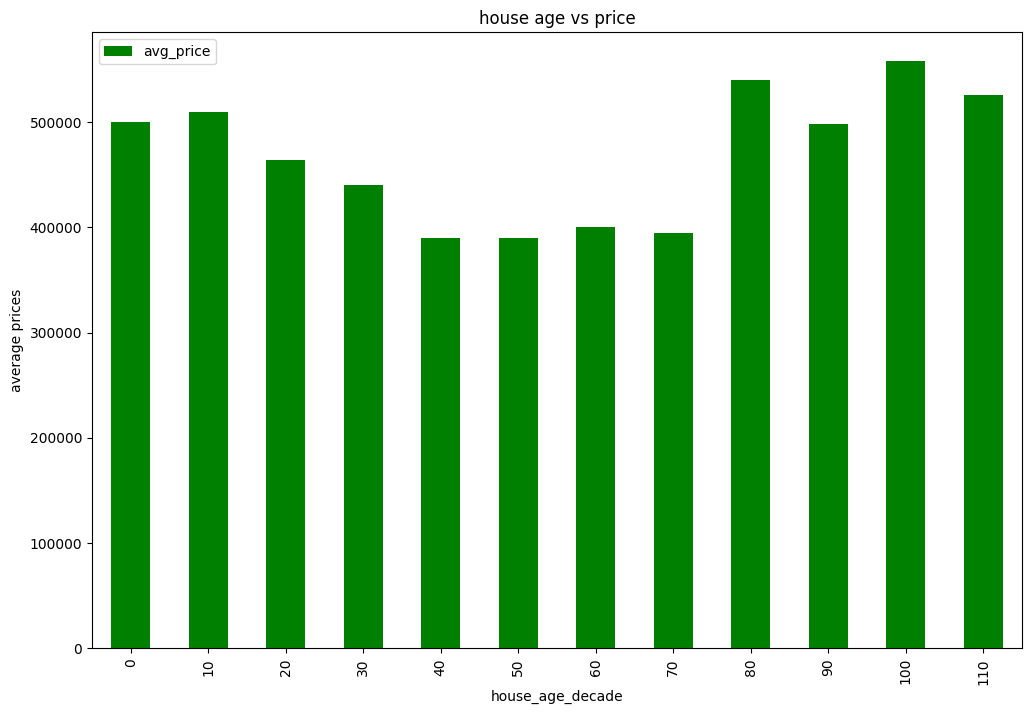

In [29]:
house_age_price.plot(x='house_age_decade', y='avg_price', kind='bar', figsize=(12, 8),color='green', title="house age vs price")
plt.ylabel ("average prices")
plt.show()

## Visualization 

In [30]:
house_eng_data['yr_built'].value_counts()

yr_built
2014    559
2006    454
2005    450
2004    433
2003    422
       ... 
1933     30
1901     29
1902     27
1935     24
1934     21
Name: count, Length: 116, dtype: int64

In [31]:
# New houses withing the last 5 years
recent_5years=np.sort(house_eng_data['yr_built'].unique())[-5:]
number_houses= house_eng_data[house_eng_data['yr_built'].isin(recent_5years)].shape[0]
# print (f"number of houses: {number_houses}")
new_houses = house_eng_data[house_eng_data['yr_built'].isin(recent_5years)]
new_houses_price = new_houses.groupby("yr_built")['price'].median().reset_index().sort_values(by="price",ascending=False)
new_houses_price['yr_built'].max()

np.int64(2015)

In [32]:
new_houses_price

,yr_built,price
4,2015,629500.0
3,2014,599000.0
2,2013,565000.0
1,2012,448475.0
0,2011,440000.0


In [33]:
def add_label(x, y):
    for i, val in enumerate(y):
        plt.text(i, val + (max(y) * 0.02),   # small offset
                 f"{val/1_000_000:.3f}M",
                 ha="center", va="bottom")


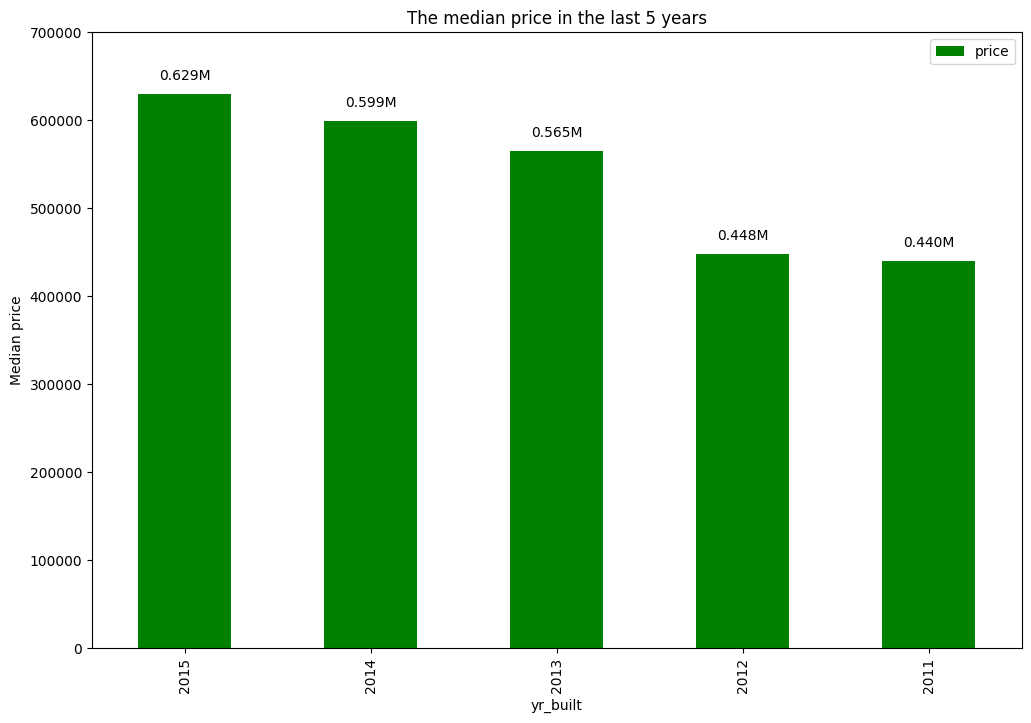

In [34]:
new_houses_price.plot(x="yr_built",y='price',kind="bar",color="green",figsize=(12,8),title="The median price in the last 5 years")
add_label(new_houses_price['yr_built'],new_houses_price['price'].astype('int64'))
plt.ylabel("Median price")
plt.yticks(np.arange(0,800000,100000))
plt.show()

In [35]:
report_rencent_5years=f'''
Houses built in the last 5 years were : {number_houses} houses.
The highest median price in {new_houses_price['yr_built'].max()} was {new_houses_price['price'].max()}

'''

report_rencent_5years

'\nHouses built in the last 5 years were : 1098 houses.\nThe highest median price in 2015 was 629500.0\n\n'

## Visualization and estimation of house size ratio fror price

In [36]:

size_ratio_cols=['sqft_basement_flag',
'basement_ratio',
'living_lot_ratio',
'sqft_living_diff',
'sqft_lot_diff',
'above_ratio',
'price']

size_ratio_features= house_eng_data.loc[:,size_ratio_cols]
size_ratio_features

,sqft_basement_flag,basement_ratio,living_lot_ratio,sqft_living_diff,sqft_lot_diff,above_ratio,price
0,0,0.00,0.21,160,0,1.00,221900.0
1,1,0.16,0.35,880,397,0.84,538000.0
2,0,0.00,0.08,1950,1938,1.00,180000.0
3,1,0.46,0.39,600,0,0.54,604000.0
4,0,0.00,0.21,120,577,1.00,510000.0
...,...,...,...,...,...,...,...
21608,0,0.00,1.35,0,378,1.00,360000.0
21609,0,0.00,0.40,480,1387,1.00,400000.0
21610,0,0.00,0.76,0,657,1.00,402101.0
21611,0,0.00,0.67,190,1101,1.00,400000.0


In [37]:
for col in size_ratio_features.columns:
    print(f"{col}")
    print(size_ratio_features[col].value_counts().reset_index().sort_values(by=col))

sqft_basement_flag
   sqft_basement_flag  count
0                   0  13126
1                   1   8487
basement_ratio
    basement_ratio  count
0             0.00  13126
57            0.01      3
52            0.02      3
48            0.03     12
47            0.04     15
..             ...    ...
62            0.60      1
61            0.61      1
60            0.62      1
64            0.64      1
58            0.67      1

[65 rows x 2 columns]
living_lot_ratio
     living_lot_ratio  count
72               0.00     41
31               0.01    243
38               0.02    225
42               0.03    188
41               0.04    222
..                ...    ...
188              2.13      1
180              2.19      1
179              2.29      1
176              4.06      1
178              4.65      1

[191 rows x 2 columns]
sqft_living_diff
     sqft_living_diff  count
0                   0   2566
346                 1      2
554                 2      1
673                 3 

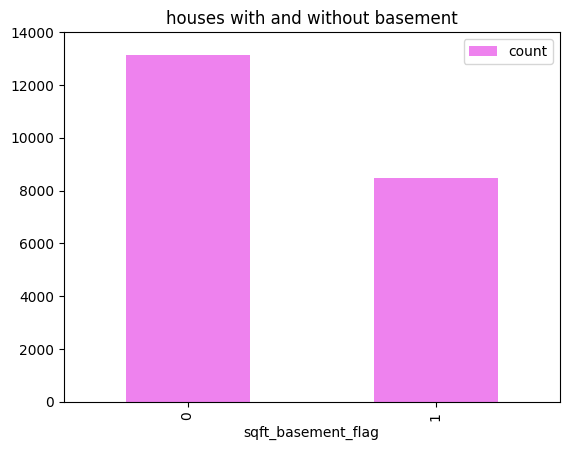

In [38]:
# Houses with basement
basement_flag = size_ratio_features['sqft_basement_flag'].value_counts().reset_index().sort_values(by='sqft_basement_flag')
basement_flag.plot("sqft_basement_flag","count",kind="bar",color="violet")
plt.title("houses with and without basement")
plt.yticks(np.arange(0,15000,2000))
plt.show()

In [39]:
ratios={}
for ratio in size_ratio_features.columns:
    ratios[ratio] = (
        size_ratio_features
        .groupby(ratio)['price']
        .median()
        .reset_index(name="median_price")
        .sort_values(by="median_price", ascending=False)
    )
ratios


{'sqft_basement_flag':    sqft_basement_flag  median_price
 1                   1      515000.0
 0                   0      411500.0,
 'basement_ratio':     basement_ratio  median_price
 59            0.59      970000.0
 61            0.61      780000.0
 57            0.57      735000.0
 2             0.02      709050.0
 62            0.62      675000.0
 ..             ...           ...
 55            0.55      390000.0
 56            0.56      337000.0
 60            0.60      245000.0
 1             0.01      220000.0
 64            0.67      205000.0
 
 [65 rows x 2 columns],
 'living_lot_ratio':      living_lot_ratio  median_price
 189              4.06     1234570.0
 173              1.75      910000.0
 187              2.19      742000.0
 190              4.65      700000.0
 185              2.09      700000.0
 ..                ...           ...
 119              1.19      325000.0
 13               0.13      310000.0
 149              1.49      307300.0
 180              1.87  

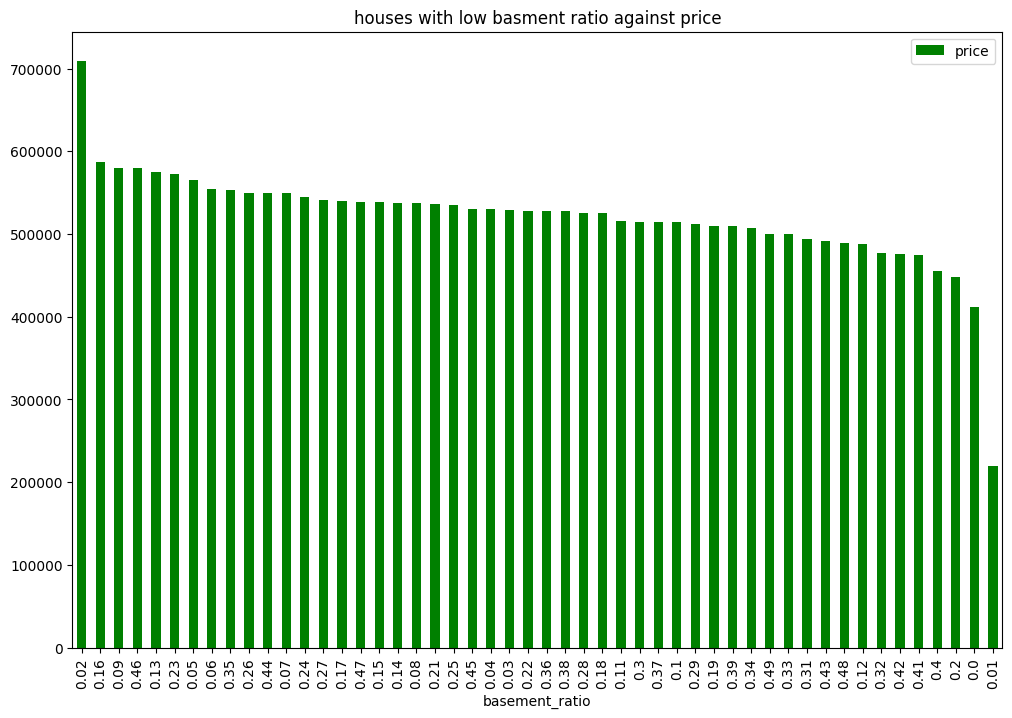

In [40]:
# Basement ratio for houses
basement_ratio = ratios["basement_ratio"]
# Basement ration < 0.5
basement_less = size_ratio_features[size_ratio_features['basement_ratio']<0.5]
basement_low=basement_less.groupby('basement_ratio')['price'].median().reset_index().sort_values(by='price',ascending=False)
basement_low.plot("basement_ratio",'price',kind='bar',figsize=(12,8) ,color='green')
plt.title("houses with low basment ratio against price")
plt.show()

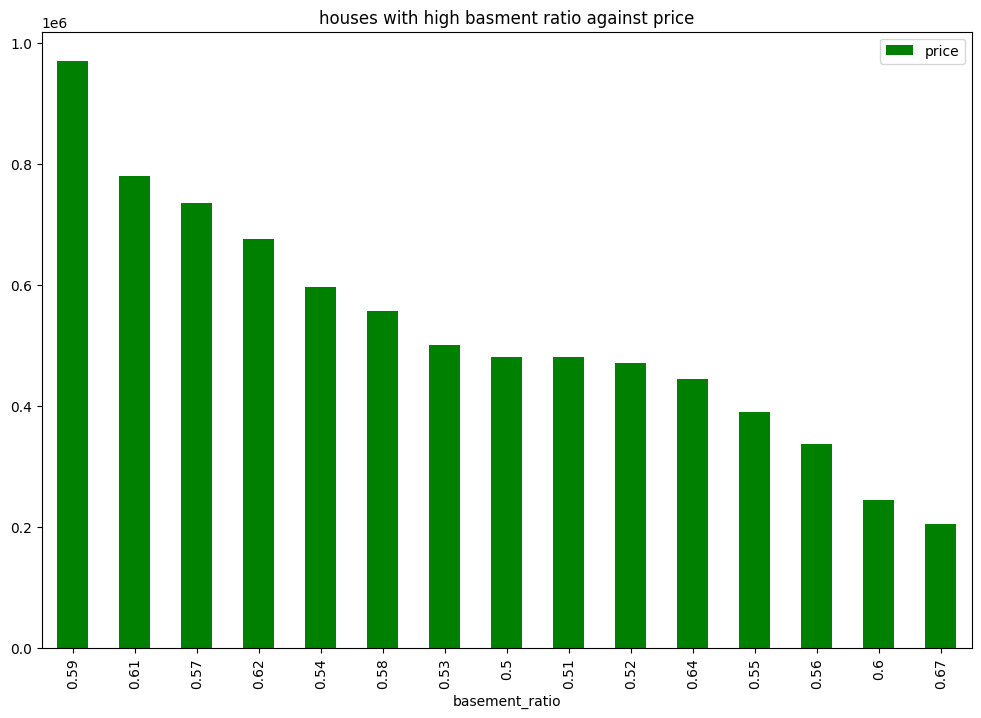

In [41]:
# Basement ratio >= 0.5
basement_high = size_ratio_features[size_ratio_features['basement_ratio']>=0.5]
basement_highest=basement_high.groupby('basement_ratio')['price'].median().reset_index().sort_values(by='price',ascending=False)
basement_highest.plot("basement_ratio",'price',kind='bar',figsize=(12,8) ,color='green')
plt.title("houses with high basment ratio against price")
plt.show()

C:\Users\hanya\AppData\Local\Temp\ipykernel_12696\3307758401.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title=" house liviging lot", loc="upper right")


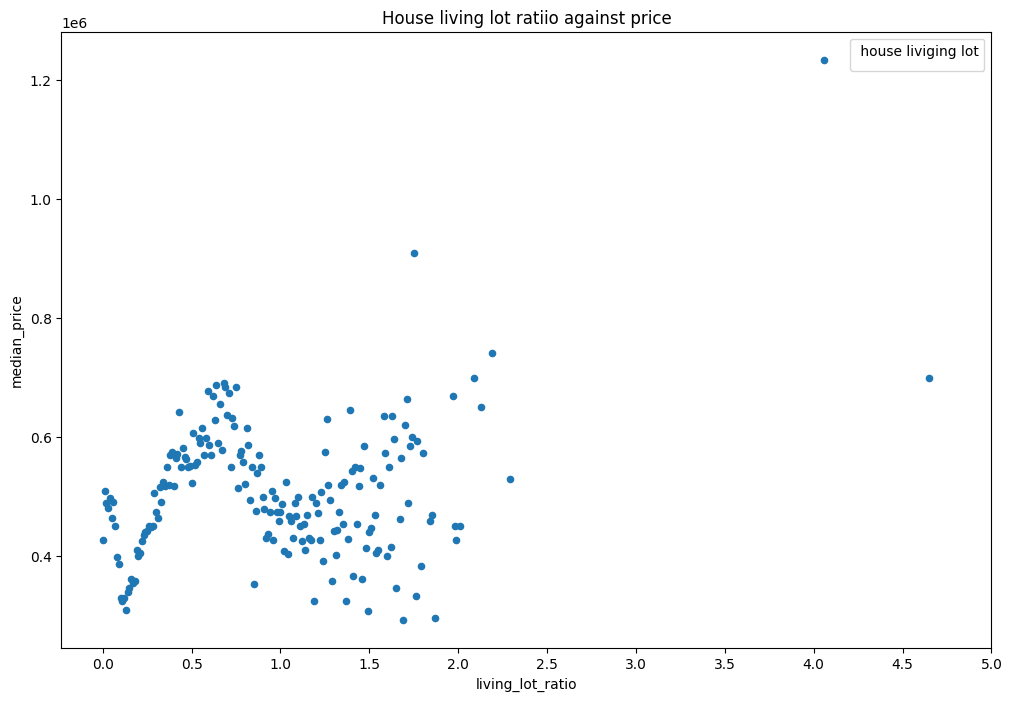

In [42]:
# living lot ratio
living_lot_ratio= ratios["living_lot_ratio"]
living_lot_ratio.plot("living_lot_ratio","median_price",kind='scatter',figsize=(12,8))
plt.title("House living lot ratiio against price")
plt.legend(title=" house liviging lot", loc="upper right")
plt.xticks(np.arange(0,5.5,0.5))
plt.show()

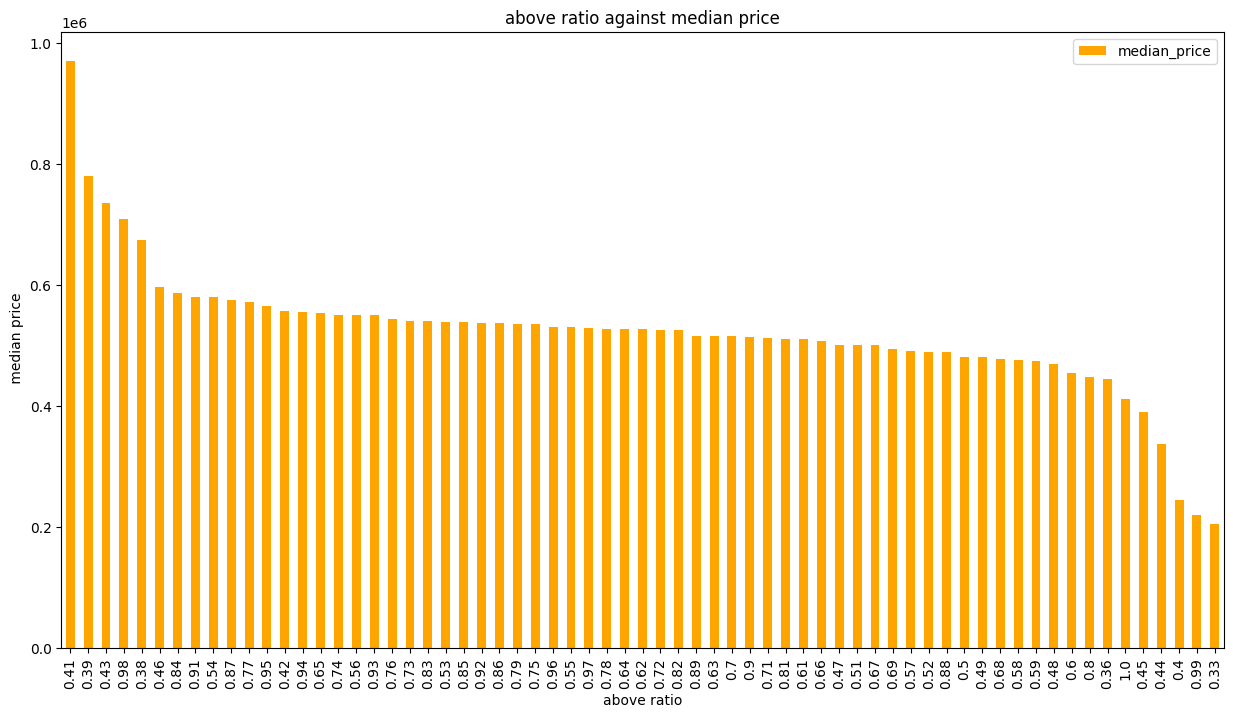

In [43]:
# above ratio
above_ratio = ratios['above_ratio']
above_ratio.plot("above_ratio","median_price",kind='bar',figsize=(15,8),color="orange")
plt.title("above ratio against median price")
plt.xlabel("above ratio")
plt.ylabel(" median price")
plt.show()

## Rooms 

- total_rooms` = bedrooms + bathrooms
- `bath_bed_ratio` = bathrooms / bedrooms (handle divide-by-zero)
- `rooms_per_floor` = total_rooms / floors

In [44]:
# Calculating and adding rooms_per_floor ratio (total_rooms/floors)
house_eng_data = preprocess.feature_engineer(
	house_eng_data,
	**{'rooms_per_floor': {'cols': ["total_rooms", "floors"], 'math': 'div'}}
)
rooms = ['total_rooms',"bath_bed_ratio","rooms_per_floor","price"]
rooms_df = house_eng_data[rooms]
print ("shape:",rooms_df.shape)
print ("cols names",rooms_df.columns)
rooms_df.info()

shape: (21613, 4)
cols names Index(['total_rooms', 'bath_bed_ratio', 'rooms_per_floor', 'price'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   total_rooms      21613 non-null  float64
 1   bath_bed_ratio   21600 non-null  float64
 2   rooms_per_floor  21613 non-null  float64
 3   price            21613 non-null  float64
dtypes: float64(4)
memory usage: 675.5 KB


In [45]:
house_eng_data[house_eng_data['bath_bed_ratio'].isnull()]
'''
bath_bed_ratio as 13 recored np.nan becuae the 13 bedrooms are 0 
this is corrected by filling np.nan (fillna()) with 0 
'''

'\nbath_bed_ratio as 13 recored np.nan becuae the 13 bedrooms are 0 \nthis is corrected by filling np.nan (fillna()) with 0 \n'

In [46]:
house_eng_data[house_eng_data['bedrooms']==0].head()
"""
Houses with 0 bedrooms are large houses with multiple floors and reaching up to 1M in price
So, they are not studios
the decision is to drop the 13 records with 0 bedromms as we have 21K+ recoreds 
"""

'\nHouses with 0 bedrooms are large houses with multiple floors and reaching up to 1M in price\nSo, they are not studios\nthe decision is to drop the 13 records with 0 bedromms as we have 21K+ recoreds \n'

In [47]:
# Dropping the 13 zero bedrooms recored
house_eng_data = house_eng_data[house_eng_data['bedrooms'] != 0].copy()
house_eng_data.shape

(21600, 49)

In [48]:
# Refressing the rooms_df
rooms_df = house_eng_data[rooms]
print ("shape:",rooms_df.shape)
print ("cols names",rooms_df.columns)
rooms_df.info()

shape: (21600, 4)
cols names Index(['total_rooms', 'bath_bed_ratio', 'rooms_per_floor', 'price'], dtype='str')
<class 'pandas.DataFrame'>
Index: 21600 entries, 0 to 21612
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   total_rooms      21600 non-null  float64
 1   bath_bed_ratio   21600 non-null  float64
 2   rooms_per_floor  21600 non-null  float64
 3   price            21600 non-null  float64
dtypes: float64(4)
memory usage: 843.8 KB


In [51]:
rooms_df.columns

Index(['total_rooms', 'bath_bed_ratio', 'rooms_per_floor', 'price'], dtype='str')

C:\Users\hanya\AppData\Local\Temp\ipykernel_12696\1245732763.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(feature, median_price,c=color)


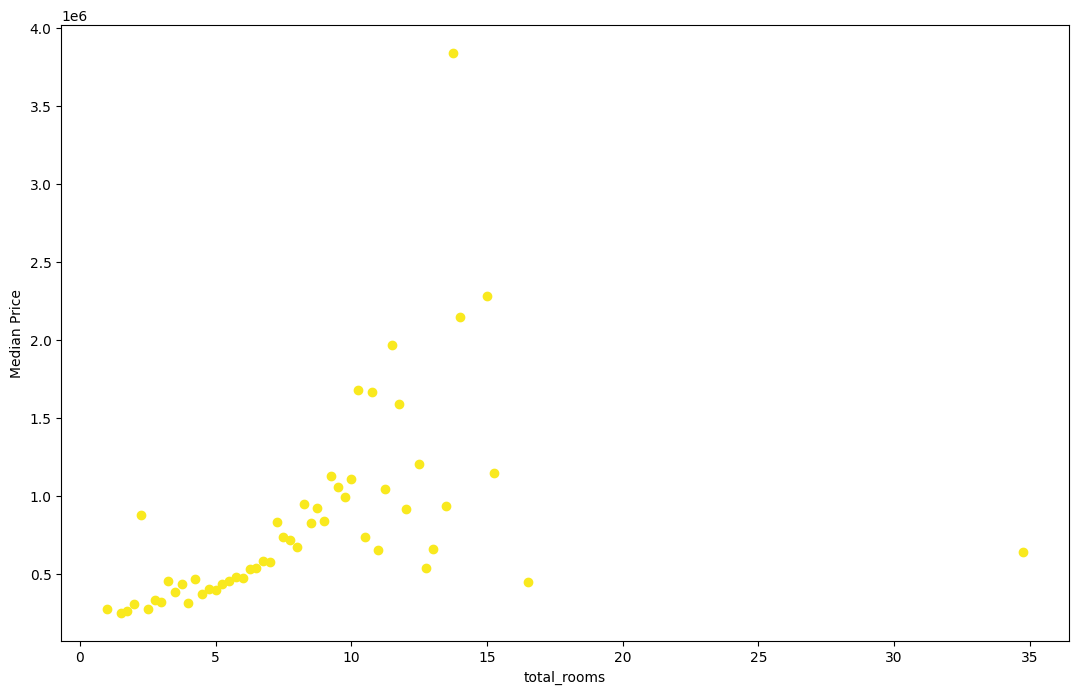

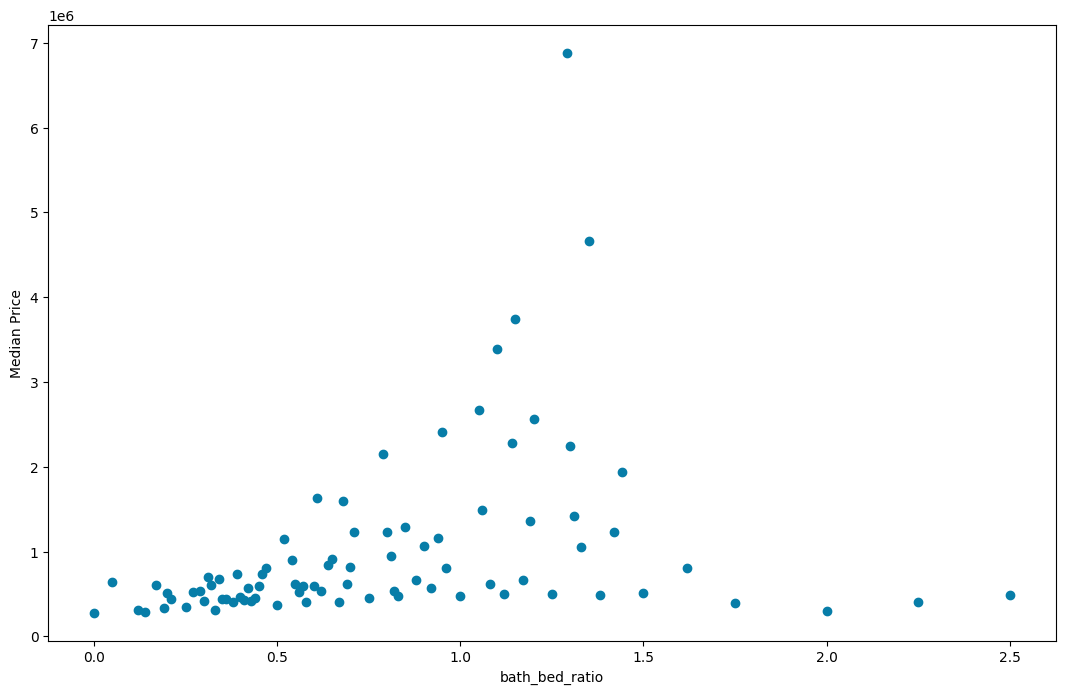

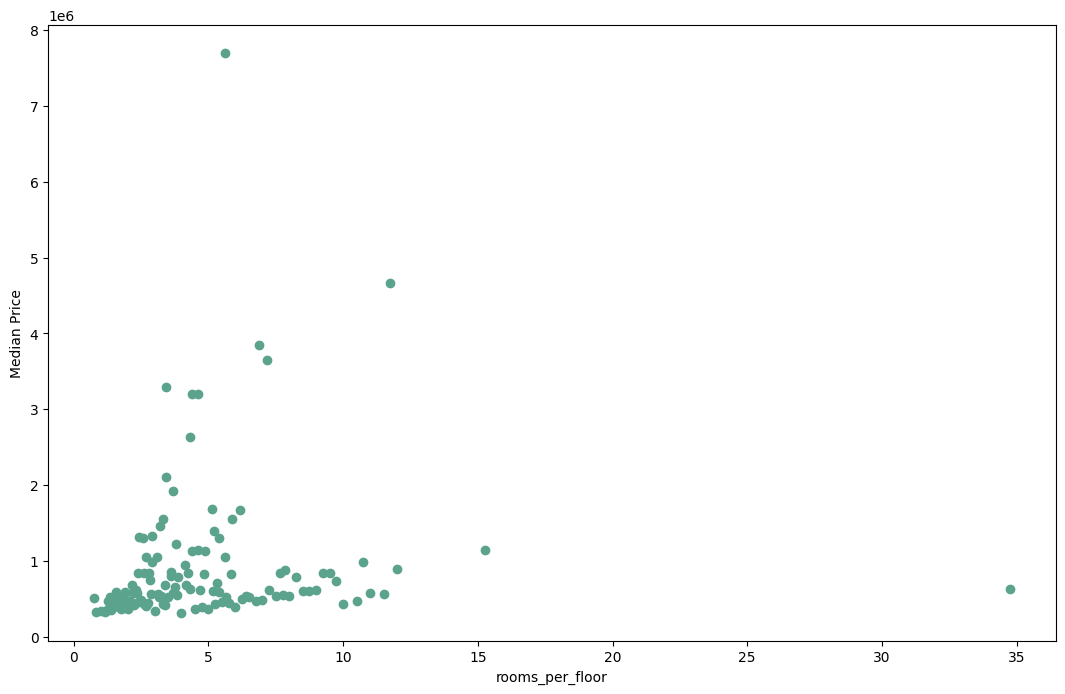

In [52]:
# Visualization of rooms 
rooms_dict={}
for room in rooms_df.columns[:-1]:
    rooms_dict[room]= rooms_df.groupby(room)['price'].median()\
        .reset_index()\
        .sort_values(by="price",ascending=False)\
        .rename(columns={"price":"median_price"})
# print (rooms_dict)

for key, value in rooms_dict.items():
    feature=value.iloc[:,0]
    median_price=value.iloc[:,1]
    color= np.random.rand(3)
    plt.figure(figsize=(13,8))
    plt.scatter(feature, median_price,c=color)
    plt.xlabel(key)
    plt.ylabel("Median Price")
    plt.show()



In [53]:
rooms_dict


{'total_rooms':     total_rooms  median_price
 48        13.75     3842500.0
 50        15.00     2280000.0
 49        14.00     2150000.0
 41        11.50     1970000.0
 36        10.25     1681000.0
 38        10.75     1665000.0
 42        11.75     1592450.0
 44        12.50     1210000.0
 51        15.25     1148000.0
 32         9.25     1127500.0
 35        10.00     1112500.0
 33         9.50     1060000.0
 40        11.25     1049500.0
 34         9.75      995000.0
 28         8.25      950500.0
 47        13.50      939999.5
 30         8.75      923725.0
 43        12.00      917000.0
 4          2.25      881750.0
 31         9.00      840750.0
 24         7.25      837352.0
 29         8.50      830000.0
 25         7.50      740000.0
 37        10.50      739000.0
 26         7.75      717250.0
 27         8.00      674100.0
 46        13.00      660000.0
 39        11.00      655000.0
 53        34.75      640000.0
 22         6.75      587000.0
 23         7.00      58

In [54]:
# # Creating a report
# with open(r"D:\House_data\src\report_text.txt","a") as f:
#     for feature, df in rooms_dict.items():
#         highest_categroy = df.iloc[0,0]
#         hightest_price = df.iloc[0,1]
#         # lowest values
#         lowest_category = df.iloc[-1,0]
#         lowest_price = df.iloc[-1,1]
#         # adding to the report_text
#         f.write(f"**{feature}\n")
#         f.write(f"houses with {feature.lower()}:{lowest_category} has a low median price of {lowest_price/1_000_000:.2f} M USD\n")
#         f.write(f"houses with {feature.lower()}:{highest_categroy} has a high median price of {hightest_price/1_000_000:.2f} M USD \n")


# Report

In [55]:
report_size_ratio=f'''
There is {basement_flag.iloc[0,1].astype(int)} houses with no basement at all,
There is {basement_flag.iloc[1,1]} houses with basement
** houses with basment ratio <0.5
Houses with low basement ratio: {basement_low.iloc[0,0]} has a max median price of {(basement_low.iloc[0,1])/1_000_000:.2f} M USD
houses with lower basement ratio: {basement_low.iloc[-1,0]} has the loweset price of {basement_low.iloc[-1,1]/1_000_000:.2f} M USD
** houses with basement ratio >= 0.5
Houses with high basement ratio: {basement_highest.iloc[0,0]} has a max median price of {(basement_highest.iloc[0,1])/1_000_000:.2f} M USD
houses with lower basement ratio: {basement_highest.iloc[-1,0]} has the loweset price of {basement_highest.iloc[-1,-1]/1_000_000:.2f} M USD

** living lot ratio
Houses with  living lot ratio: {living_lot_ratio.iloc[0,0]} has a max median price of {(living_lot_ratio.iloc[0,1])/1_000_000:.2f} M USD
houses with  living lot ratio: {living_lot_ratio.iloc[-1,0]} has the loweset price of {living_lot_ratio.iloc[-1,1]/1_000_000:.2f} M USD

** above ratio
Houses with  above ratio: {above_ratio.iloc[0,0]} has a max median price of {(above_ratio.iloc[0,1])/1_000_000:.2f} M USD
houses with  above ratio: {above_ratio.iloc[-1,0]} has the loweset price of {above_ratio.iloc[-1,1]/1_000_000:.2f} M USD

'''
report_size_ratio

'\nThere is 13126 houses with no basement at all,\nThere is 8487 houses with basement\n** houses with basment ratio <0.5\nHouses with low basement ratio: 0.02 has a max median price of 0.71 M USD\nhouses with lower basement ratio: 0.01 has the loweset price of 0.22 M USD\n** houses with basement ratio >= 0.5\nHouses with high basement ratio: 0.59 has a max median price of 0.97 M USD\nhouses with lower basement ratio: 0.67 has the loweset price of 0.20 M USD\n\n** living lot ratio\nHouses with  living lot ratio: 4.06 has a max median price of 1.23 M USD\nhouses with  living lot ratio: 1.69 has the loweset price of 0.29 M USD\n\n** above ratio\nHouses with  above ratio: 0.41 has a max median price of 0.97 M USD\nhouses with  above ratio: 0.33 has the loweset price of 0.20 M USD\n\n'

In [56]:
# with open(r"D:\House_data\src\report_text.txt",'a') as f:
#     f.write(report_size_ratio)

Quality/composite scores**
- `overall_quality` = combination of grade + condition + view (weighted sum or just grade*condition)
- `luxury_score` = combine waterfront + view + grade — likely a strong price driver

**Interaction terms**
- `grade * sqft_living` — bigger, higher-grade homes compound in value
- `waterfront * view` — waterfront homes with good views are premium

In [57]:
# feature interaction schema
# estimation of overall quality, luxury score, 
# grade for sqft_living, waterfron for view interactions
feature_interaction_schema = {
    "overall_quality": {
        "cols": ["grade", "condition"],
        "math": "mult"
    },
    "luxury_score": {
        "cols": ["waterfront", "grade"],
        "math": "adding"
    },
    "grade_sqft_living": {
        "cols": ["grade", "sqft_living"],
        "math": "mult"
    },
    "waterfront_view_interaction": {
        "cols": ["waterfront", "view"],
        "math": "mult"
    }
}

house_eng_data = preprocess.feature_engineer(house_eng_data, **feature_interaction_schema)
print (house_eng_data.shape)
interaction_feature = house_eng_data[["overall_quality",'luxury_score','grade_sqft_living', 'waterfront_view_interaction','price']]
interaction_feature

(21600, 49)


,overall_quality,luxury_score,grade_sqft_living,waterfront_view_interaction,price
0,21,7,8260,0,221900.0
1,21,7,17990,0,538000.0
2,18,6,4620,0,180000.0
3,35,7,13720,0,604000.0
4,24,8,13440,0,510000.0
...,...,...,...,...,...
21608,24,8,12240,0,360000.0
21609,24,8,18480,0,400000.0
21610,21,7,7140,0,402101.0
21611,24,8,12800,0,400000.0


In [58]:
for col in interaction_feature.columns:
    print (interaction_feature[col].info())
    print (interaction_feature[col].value_counts().reset_index().sort_values(by=col))

<class 'pandas.Series'>
Index: 21600 entries, 0 to 21612
Series name: overall_quality
Non-Null Count  Dtype
--------------  -----
21600 non-null  int64
dtypes: int64(1)
memory usage: 337.5 KB
None
    overall_quality  count
31                4      1
25                5      9
22                6     12
27                7      6
26                8      6
30                9      1
20               10     15
15               12     71
14               14     75
12               15    101
19               16     23
6                18   1037
13               20     86
0                21   5229
1                24   4951
18               25     34
3                27   2041
2                28   2832
5                30   1169
4                32   1394
10               33    332
7                35    833
9                36    519
24               39     11
8                40    546
16               44     56
11               45    126
21               48     13
17               50 

{'overall_quality':     overall_quality  median_price
29               52     5750000.0
23               39     2888000.0
27               48     2125000.0
30               55     2050000.0
31               60     1990000.0
25               44     1685000.0
28               50     1650000.0
20               33     1209500.0
26               45     1078000.0
22               36      875000.0
18               30      810000.0
24               40      772000.0
16               27      689000.0
19               32      571250.0
14               24      457000.0
21               35      456000.0
3                 7      403500.0
17               28      390000.0
13               21      357950.0
10               16      352000.0
8                14      305000.0
11               18      265000.0
2                 6      262500.0
9                15      238950.0
4                 8      235000.0
12               20      230000.0
15               25      227450.0
7                12      219

C:\Users\hanya\AppData\Local\Temp\ipykernel_12696\1657872893.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(feature, median_price,c=color)


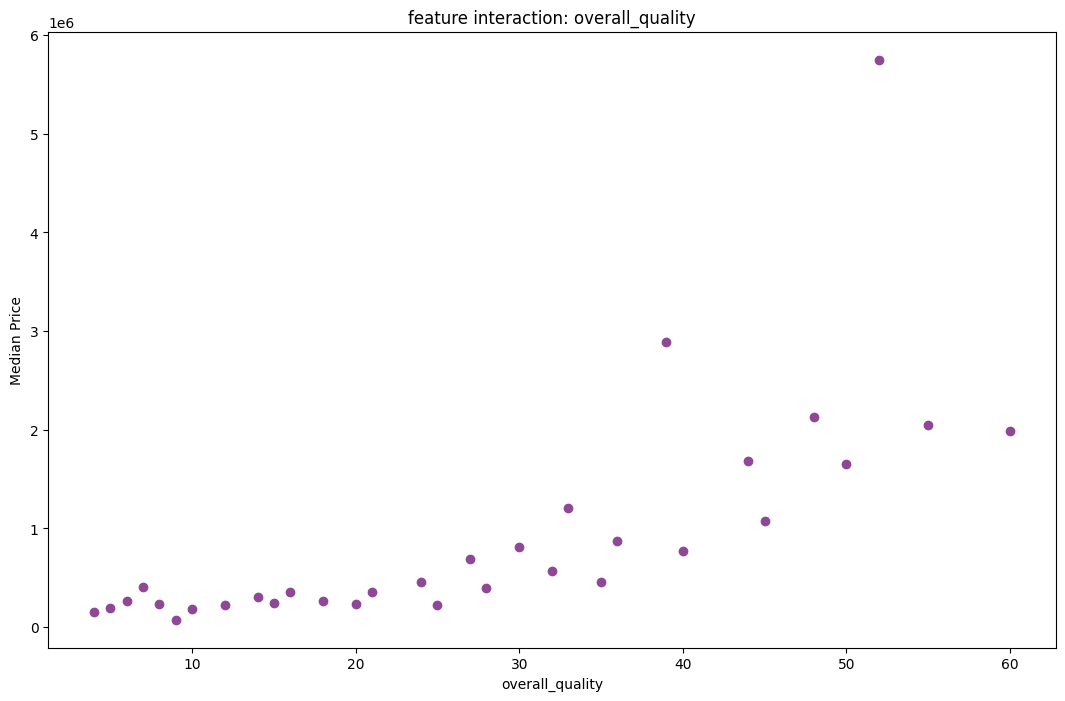

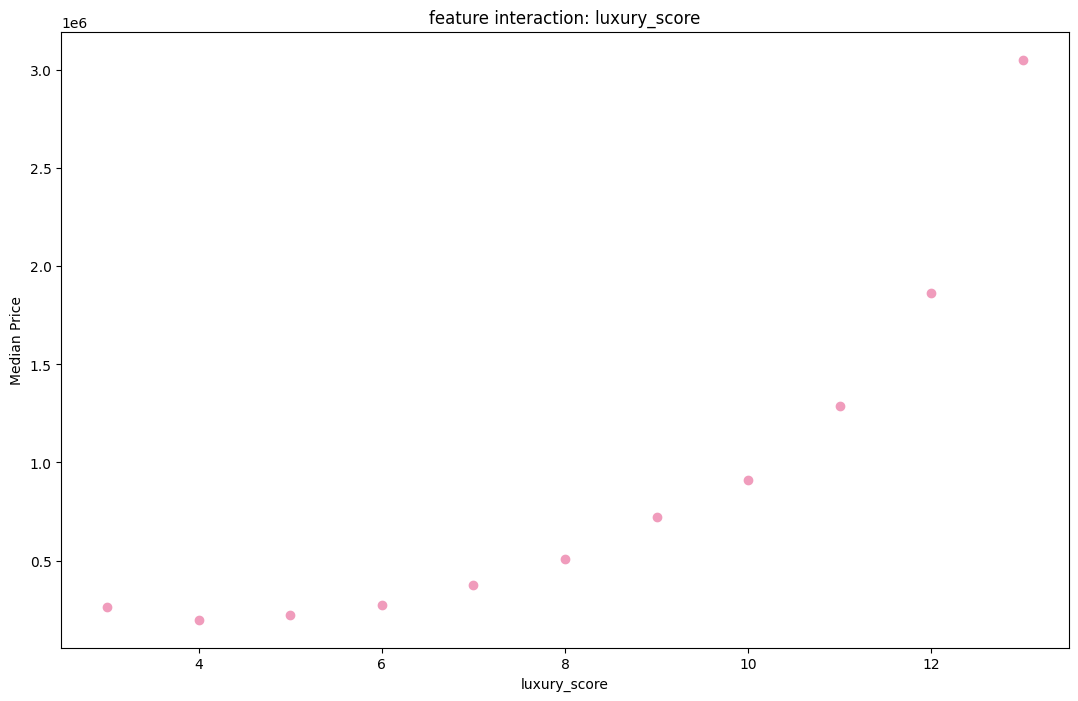

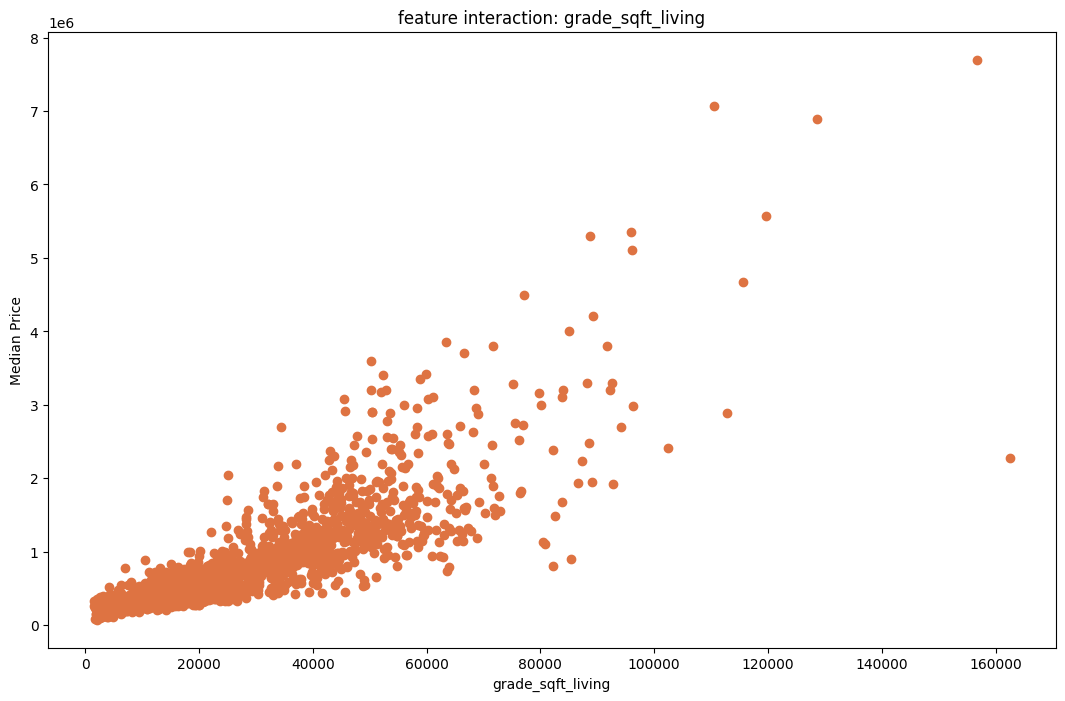

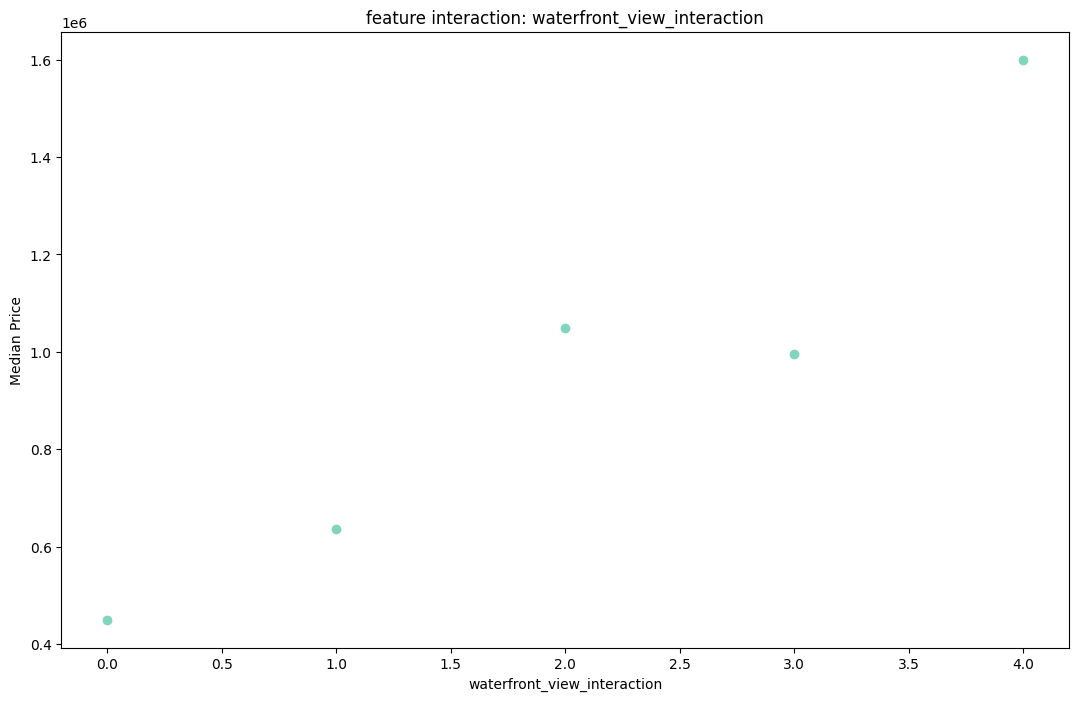

In [59]:
# visualization of interaction
interaction_dict={}
for feature in interaction_feature.columns[:-1]:
    interaction_dict[feature]= interaction_feature.groupby(feature)['price'].median()\
        .reset_index()\
        .sort_values(by="price",ascending=False)\
        .rename(columns={"price":"median_price"})
print (interaction_dict)

for key, value in interaction_dict.items():
    feature=value.iloc[:,0]
    median_price=value.iloc[:,1]
    color= np.random.rand(3)
    plt.figure(figsize=(13,8))
    plt.scatter(feature, median_price,c=color)
    plt.title(f"feature interaction: {key}")
    plt.xlabel(key)
    plt.ylabel("Median Price")
    plt.show()

In [60]:
# # create the interaction report
# # Creating a report
# with open(r"D:\House_data\src\report_text.txt","a") as f:
#     for feature, df in interaction_dict.items():
#         highest_categroy = df.iloc[0,0]
#         hightest_price = df.iloc[0,1]
#         # lowest values
#         lowest_category = df.iloc[-1,0]
#         lowest_price = df.iloc[-1,1]
#         # adding to the report_text
#         f.write(f"**{feature}\n")
#         f.write(f"houses with {feature.lower()}:{lowest_category} has a low median price of {lowest_price/1_000_000:.2f} M USD\n")
#         f.write(f"houses with {feature.lower()}:{highest_categroy} has a high median price of {hightest_price/1_000_000:.2f} M USD \n")


*************************************************************************************************

In [ ]:
house_eng_data1 = pd.read_csv(r"D:\House_data\raw_data\house_eng_data.csv")
print(*house_eng_data1.columns,sep='\n')

In [84]:
house_eng_data1.drop(["id","date",'bedrooms_flag'],axis=1,inplace=True,errors='ignore')
house_eng_data1.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,sqft_living_diff,sqft_lot_diff,above_ratio,total_rooms,bath_bed_ratio,overall_quality,luxury_score,grade_sqft_living,waterfront_view_interaction,rooms_per_floor
price,1.000000,0.308890,0.525874,0.701911,0.089827,0.256876,0.266432,0.397326,0.036120,0.667764,...,0.419995,0.049136,-0.135531,0.467356,0.281899,0.490873,0.681418,0.756231,0.267147,0.075806
bedrooms,0.308890,1.000000,0.514981,0.578405,0.032325,0.178178,-0.006800,0.080079,0.026704,0.357145,...,0.216330,0.002335,-0.195374,0.894954,-0.234774,0.266114,0.353537,0.506891,-0.004690,0.512199
bathrooms,0.525874,0.514981,1.000000,0.755827,0.088184,0.502638,0.063744,0.188403,-0.126155,0.666080,...,0.291208,0.044703,-0.128259,0.843332,0.652692,0.342565,0.664936,0.738963,0.065877,0.166913
sqft_living,0.701911,0.578405,0.755827,1.000000,0.173342,0.354071,0.103856,0.284726,-0.059284,0.762707,...,0.471854,0.088696,-0.207326,0.756005,0.310856,0.465813,0.763653,0.973756,0.104807,0.197053
sqft_lot,0.089827,0.032325,0.088184,0.173342,1.000000,-0.004861,0.021627,0.074883,-0.008863,0.114473,...,0.169002,0.829894,0.029301,0.066163,0.063341,0.069108,0.115056,0.172855,0.017761,0.041111
floors,0.256876,0.178178,0.502638,0.354071,-0.004861,1.000000,0.023765,0.028851,-0.263944,0.458790,...,0.043561,-0.001812,0.345478,0.373317,0.418903,0.083022,0.456530,0.373393,0.024770,-0.640960
waterfront,0.266432,-0.006800,0.063744,0.103856,0.021627,0.023765,1.000000,0.401972,0.016617,0.082861,...,0.088591,0.024255,-0.035684,0.028915,0.080314,0.072801,0.155215,0.113189,0.989043,-0.005039
view,0.397326,0.080079,0.188403,0.284726,0.074883,0.028851,0.401972,1.000000,0.046020,0.251661,...,0.182649,0.055915,-0.171926,0.148263,0.132605,0.217791,0.278843,0.300204,0.406941,0.085260
condition,0.036120,0.026704,-0.126155,-0.059284,-0.008863,-0.263944,0.016617,0.046020,1.000000,-0.146277,...,0.026843,-0.003506,-0.189999,-0.048920,-0.156923,0.733955,-0.143789,-0.085411,0.013905,0.220299
grade,0.667764,0.357145,0.666080,0.762707,0.114473,0.458790,0.082861,0.251661,-0.146277,1.000000,...,0.239325,0.049237,-0.000474,0.570582,0.408658,0.552996,0.997345,0.848131,0.084391,-0.010005


In [82]:
house_eng_data1.date

0        2014-10-13
1        2014-12-09
2        2015-02-25
3        2014-12-09
4        2015-02-18
            ...    
21595    2014-05-21
21596    2015-02-23
21597    2014-06-23
21598    2015-01-16
21599    2014-10-15
Name: date, Length: 21600, dtype: str

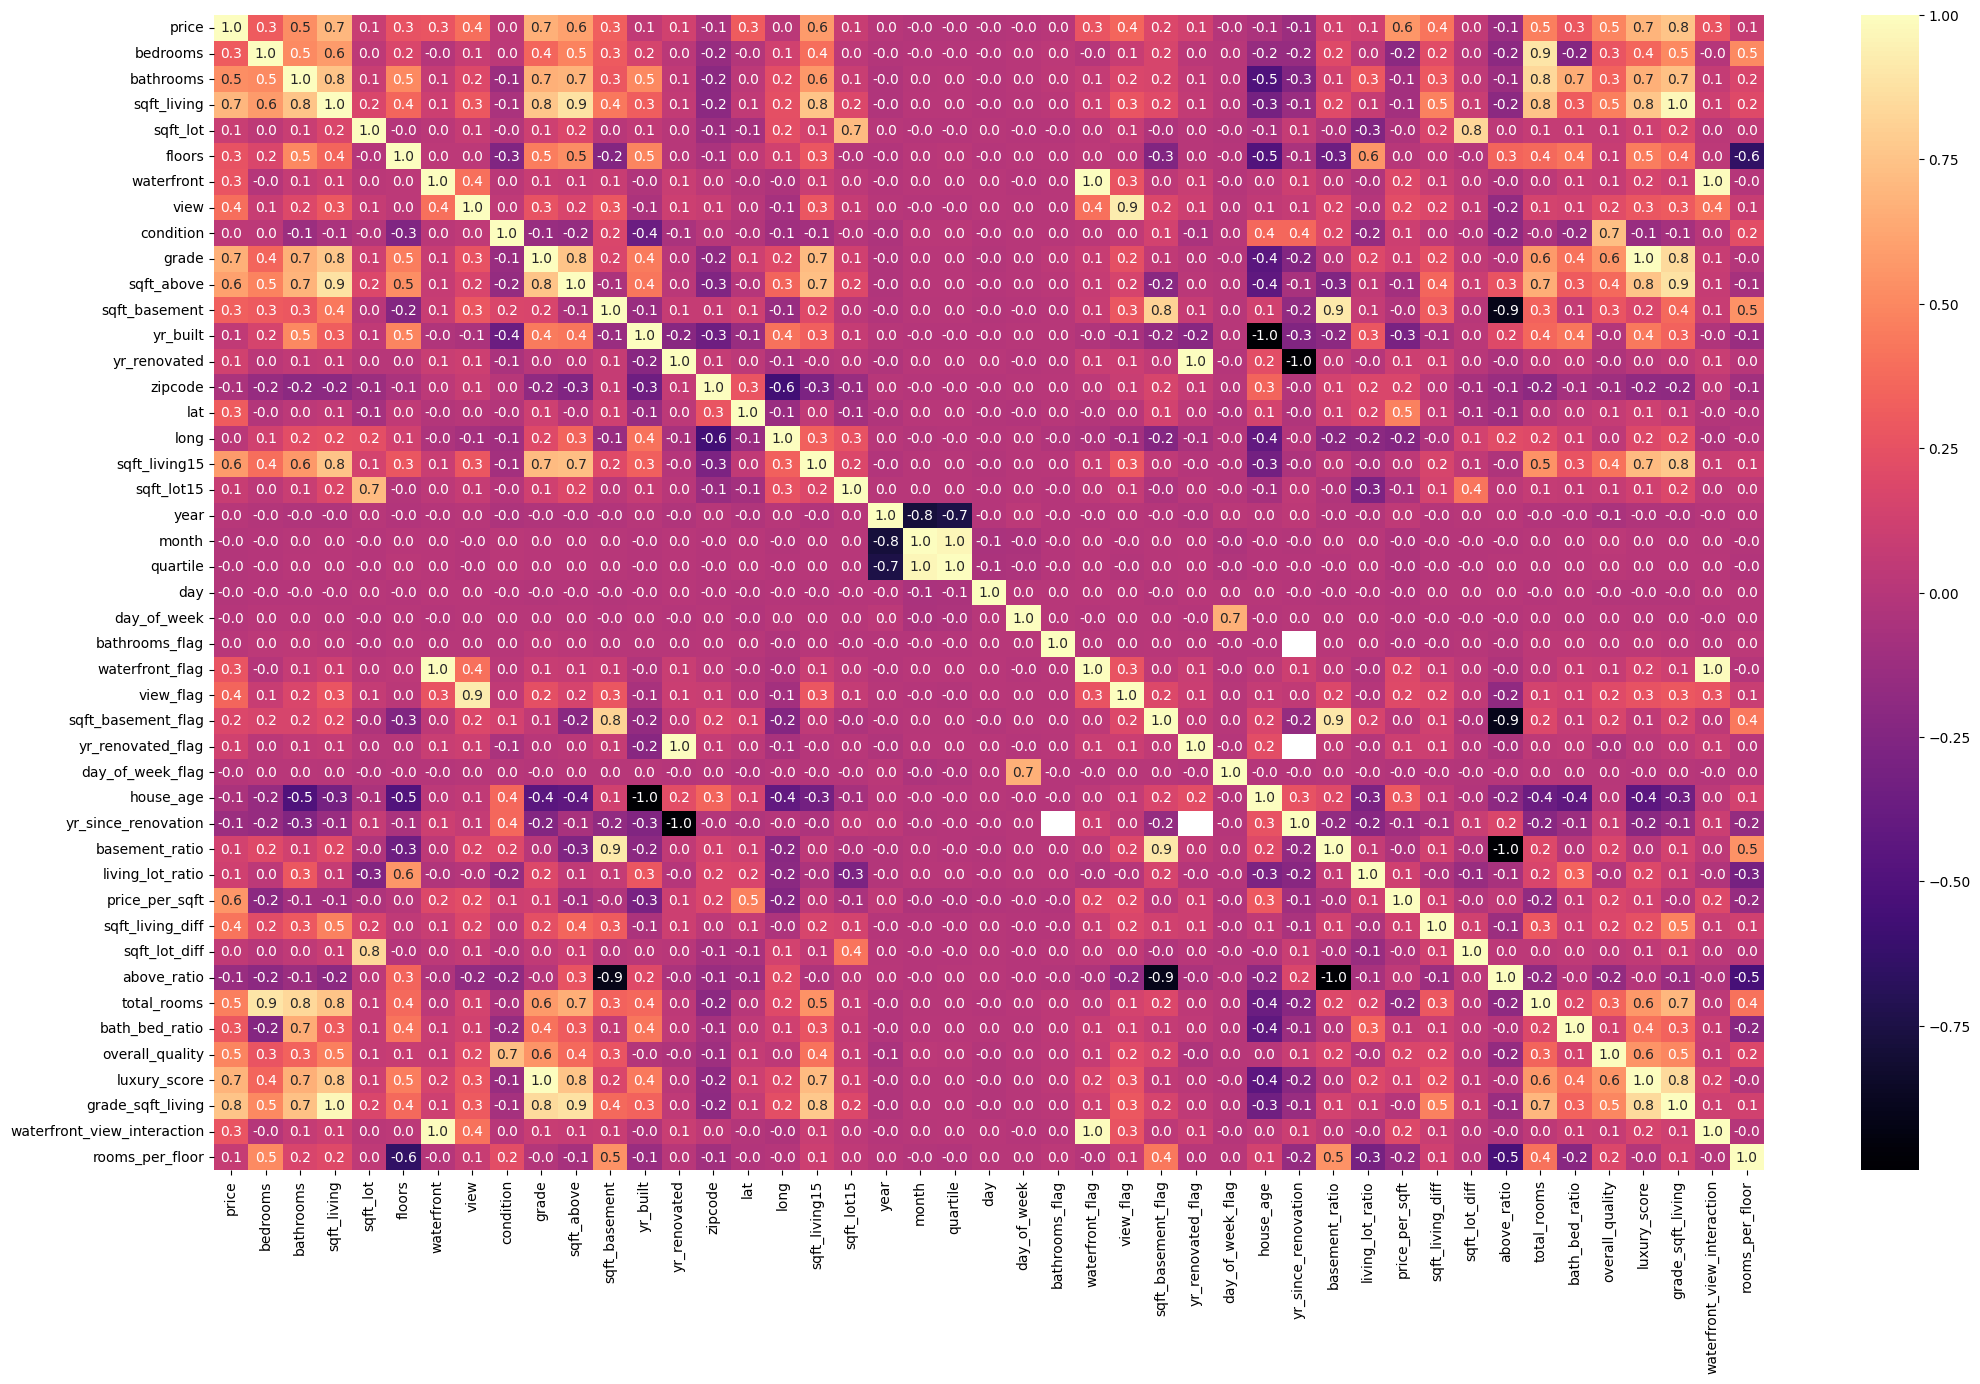

In [92]:
plt.figure(figsize=(25,15))
corr = house_eng_data1.corr()
sns.heatmap(corr, annot=True, fmt='.1f', cmap='magma')
plt.show()

In [107]:
price_corr = corr['price']
max_price_corr = price_corr[price_corr<0.6]
max_price_corr

bedrooms                       0.308890
bathrooms                      0.525874
sqft_lot                       0.089827
floors                         0.256876
waterfront                     0.266432
view                           0.397326
condition                      0.036120
sqft_basement                  0.323815
yr_built                       0.054019
yr_renovated                   0.126429
zipcode                       -0.053347
lat                            0.306855
long                           0.021831
sqft_living15                  0.585289
sqft_lot15                     0.082752
year                           0.003691
month                         -0.009921
quartile                      -0.008321
day                           -0.014650
day_of_week                   -0.001697
bathrooms_flag                 0.008363
waterfront_flag                0.266432
view_flag                      0.359153
sqft_basement_flag             0.180148
yr_renovated_flag              0.126087
